# NB05 — Predict full network

**Purpose**: Apply the model selected in NB04 to all Rotterdam intersections that
have a reprojected photo available, producing one predicted safety score per
intersection for use in the Negative Binomial crash model (Phase 3).

**Coverage**: 4,615 intersections were selected for reprojection; **926 have photos**
(3,689 lacked source panoramas and are skipped). The `cv_split` column in the
output CSV makes the train/val/unlabelled boundary explicit so the NB model test
set can exclude CV training intersections.

**Inputs**:
- `outputs/model_selection.json` — selected backbone + checkpoint (from NB04)
- `outputs/resnet50_best.pt` — regression head checkpoint
- `outputs/split_assignment.csv` — train/val labels for labelled intersections
- `intersections/data/processed/full_city_leg_selection.csv` — one row per
  intersection that has a reprojected photo
- `features/resnet50/` — cached feature tensors (reused where available)
- Reprojected JPEGs at `FULL_CITY_REPRO_ROOT/{intersection_id}/leg_{bearing:.0f}.jpeg`

**Outputs**:
- `outputs/cv_scores_full_network.csv` — `intersection_id`, `cv_score_predicted`, `cv_split`
- `outputs/missing_photos.csv` — intersections skipped due to missing photo
- `outputs/nb05_spatial_map.png` — predicted scores on Rotterdam map (thesis-ready)
- `outputs/nb05_score_distribution.png` — score distribution by stratum

---

**Imports**

In [26]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.models as tv_models
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

warnings.filterwarnings("ignore", category=UserWarning)

**Configuration** — all paths as named constants.

In [27]:
CV_ROOT      = Path("..")
PROJECT_ROOT = CV_ROOT / ".."   # cv/pipeline/ → cv/ → project root
OUTPUTS_DIR  = CV_ROOT / "outputs"
FEATURES_DIR = CV_ROOT / "features"

# Reprojected photos — training set root (labelled intersections)
REPRO_ROOT = Path(
    r"D:\rotterdam_aiis_2025\vault-production\vault_v1"
    r"\reprojected_directional_fov90_dist20_new"
)
# Reprojected photos — full city (926 intersections with photos)
FULL_CITY_REPRO_ROOT = Path(
    r"D:\rotterdam_aiis_2025\vault-production\vault_v1"
    r"\reprojected_directional_fov90_dist20_full_city"
)

# Input CSVs — full_city_leg_selection.csv is kept in cv/data/raw/ (copied by update_data.py)
FULL_CITY_LEG_CSV    = CV_ROOT / "data" / "raw" / "full_city_leg_selection.csv"
SPLIT_CSV            = OUTPUTS_DIR / "split_assignment.csv"
MODEL_SELECTION_JSON = OUTPUTS_DIR / "model_selection.json"
INTERSECTIONS_GPKG   = PROJECT_ROOT / "intersections" / "data" / "processed" / "intersections_stratified.gpkg"

# Output files
SCORES_CSV = OUTPUTS_DIR / "cv_scores_full_network.csv"
MISSING_CSV = OUTPUTS_DIR / "missing_photos.csv"
MAP_PNG     = OUTPUTS_DIR / "nb05_spatial_map.png"
DIST_PNG    = OUTPUTS_DIR / "nb05_score_distribution.png"

NORMALIZE_FEATURES = True   # must match the flag used during training in NB02
BATCH_SIZE         = 32
RANDOM_SEED        = 42

# Limit inference to the first N intersections for quick testing.
# Set to None to score all intersections with available photos.
DEBUG_N = 50

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device               : {device}")
print(f"FULL_CITY_REPRO_ROOT : {FULL_CITY_REPRO_ROOT}")
print(f"  exists             : {FULL_CITY_REPRO_ROOT.exists()}")
print(f"DEBUG_N              : {DEBUG_N if DEBUG_N is not None else 'all'}")

# Verify required inputs
required = [FULL_CITY_LEG_CSV, SPLIT_CSV, MODEL_SELECTION_JSON]
missing  = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing inputs: {missing}")
print("All required inputs found.")

Device               : cpu
FULL_CITY_REPRO_ROOT : D:\rotterdam_aiis_2025\vault-production\vault_v1\reprojected_directional_fov90_dist20_full_city
  exists             : True
DEBUG_N              : 50
All required inputs found.


## 1. Load data and build intersection list

The full-city leg CSV already encodes which intersections have photos — one row per
intersection. The split assignment CSV supplies train/val labels for the labelled
subset. Intersections absent from the split CSV are marked `unlabelled`.

In [28]:
legs  = pd.read_csv(FULL_CITY_LEG_CSV)
split = pd.read_csv(SPLIT_CSV)

# The split CSV was produced from the augmented BT set; keep originals only
# (augmented copies are not present in the full-city leg CSV)
split_orig = split[~split["sample_id"].str.endswith("_aug")].copy()
split_orig["intersection_id"] = split_orig["intersection_id"].astype(int)

# Merge cv_split onto the full-city leg list; fill missing with 'unlabelled'
df = legs[["intersection_id", "leg_bearing", "photo_x", "photo_y",
           "selected_direction", "all_back", "used_fallback"]].copy()
df["intersection_id"] = df["intersection_id"].astype(int)

df = df.merge(
    split_orig[["intersection_id", "cv_split"]],
    on="intersection_id",
    how="left",
)
df["cv_split"] = df["cv_split"].fillna("unlabelled")

# Construct the expected reprojected photo path for each row.
# Labelled intersections may have photos in REPRO_ROOT; full-city ones in
# FULL_CITY_REPRO_ROOT. Try REPRO_ROOT first (it was the training source).
def resolve_photo_path(row):
    bearing = float(row["leg_bearing"]) % 360
    iid     = int(row["intersection_id"])
    fname   = f"leg_{bearing:.0f}.jpeg"
    p_orig  = REPRO_ROOT           / str(iid) / fname
    p_fc    = FULL_CITY_REPRO_ROOT / str(iid) / fname
    if p_orig.exists():
        return str(p_orig)
    if p_fc.exists():
        return str(p_fc)
    return None

print("Resolving photo paths (may take a moment for 926 rows) ...")
df["photo_path"] = df.apply(resolve_photo_path, axis=1)

found      = df["photo_path"].notna()
missing_df = df[~found].copy()
df         = df[found].reset_index(drop=True)

print(f"Intersections with photo found : {len(df)}")
print(f"Intersections with no photo    : {len(missing_df)}  (logged to missing_photos.csv)")

# Log missing photos so downstream steps know which IDs to skip
if len(missing_df):
    missing_df[["intersection_id", "leg_bearing"]].to_csv(MISSING_CSV, index=False)
    print(f"Missing photos saved to: {MISSING_CSV}")

# Apply debug limit — keeps the first N rows so testing is fast.
# Labelled intersections appear first in the CSV, so they are included in the subset.
if DEBUG_N is not None:
    df = df.head(DEBUG_N).reset_index(drop=True)
    print(f"\nDEBUG_N={DEBUG_N}: working on {len(df)} intersections.")

print(df["cv_split"].value_counts().to_string())

Resolving photo paths (may take a moment for 926 rows) ...
Intersections with photo found : 1197
Intersections with no photo    : 3758  (logged to missing_photos.csv)
Missing photos saved to: ..\outputs\missing_photos.csv

DEBUG_N=50: working on 50 intersections.
cv_split
train         23
unlabelled    22
excluded       4
val            1


## 2. Load backbone and regression head

The selected backbone and checkpoint are read from `model_selection.json` so this
notebook automatically adapts when the selection changes after retraining.

In [29]:
with open(MODEL_SELECTION_JSON) as f:
    selection = json.load(f)

BACKBONE_NAME = selection["selected_backbone"]
FEATURE_DIM   = selection["feature_dim"]
CHECKPOINT    = OUTPUTS_DIR / selection["checkpoint"]
BACKBONE_FEATURES_DIR = CV_ROOT / selection["features_dir"]
BACKBONE_FEATURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Selected backbone : {BACKBONE_NAME}")
print(f"Feature dim       : {FEATURE_DIM}")
print(f"Checkpoint        : {CHECKPOINT}")
print(f"Data note         : {selection['data_note']}")

# --- Load frozen backbone ---
if BACKBONE_NAME == "resnet50":
    backbone = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
    backbone.fc = nn.Identity()   # remove classification head; output is 2048-dim
elif BACKBONE_NAME == "dinov2_vits14":
    backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14", verbose=False)
else:
    raise ValueError(f"Unknown backbone: {BACKBONE_NAME}")

for param in backbone.parameters():
    param.requires_grad = False
backbone.eval()
backbone.to(device)

# --- Load regression head ---
# Must mirror the RegressionHead class used in NB02/NB03 exactly, because the
# checkpoint keys include the 'net.' prefix from self.net inside that class.
class RegressionHead(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, 1), nn.Sigmoid())

    def forward(self, x):
        return self.net(x).squeeze(1)

head = RegressionHead(FEATURE_DIM)
head.load_state_dict(torch.load(CHECKPOINT, weights_only=True, map_location=device))
head.eval()
head.to(device)

n_params = sum(p.numel() for p in backbone.parameters())
print(f"Backbone params (frozen) : {n_params / 1e6:.1f}M")
print(f"Head params              : {sum(p.numel() for p in head.parameters())}")

Selected backbone : resnet50
Feature dim       : 2048
Checkpoint        : ..\outputs\resnet50_best.pt
Data note         : Preliminary — based on pilot survey BT scores, not full survey data.
Backbone params (frozen) : 23.5M
Head params              : 2049


## 3. Feature extraction

Each intersection gets a unique cache key: `{intersection_id}_orig` for labelled
intersections (matching the cache written by NB02/NB03) and `{intersection_id}_fc`
for unlabelled full-city intersections. Existing cache files are reused without
re-running the backbone.

In [30]:
# Deterministic val transform — identical to NB02 so cached features are compatible
if BACKBONE_NAME == "resnet50":
    _SIZE = 224
else:
    _SIZE = 518   # DINOv2 patch_size=14 → 37×37 patches

inference_transform = transforms.Compose([
    transforms.Resize((_SIZE, _SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def cache_key(row):
    """Return the .pt filename stem for this intersection.

    Labelled intersections use the '_orig' suffix so the existing NB02/NB03
    cache files are reused directly. Unlabelled full-city rows get '_fc'.
    """
    if row["cv_split"] in ("train", "val"):
        return f"{int(row['intersection_id'])}_orig"
    return f"{int(row['intersection_id'])}_fc"


df["cache_key"] = df.apply(cache_key, axis=1)

already_cached = sum(
    1 for k in df["cache_key"]
    if (BACKBONE_FEATURES_DIR / f"{k}.pt").exists()
)
print(f"Total intersections : {len(df)}")
print(f"Already cached      : {already_cached}")
print(f"To extract          : {len(df) - already_cached}")

Total intersections : 50
Already cached      : 50
To extract          : 0


In [31]:
@torch.no_grad()
def extract_and_cache_all(df, backbone, features_dir, transform, device):
    """Run each image through the frozen backbone and cache the feature vector."""
    skipped   = 0
    extracted = 0
    errors    = []

    for idx, row in df.iterrows():
        cache_path = features_dir / f"{row['cache_key']}.pt"

        if cache_path.exists():
            skipped += 1
            continue

        try:
            img  = Image.open(row["photo_path"]).convert("RGB")
            feat = backbone(transform(img).unsqueeze(0).to(device)).squeeze(0).cpu()
            torch.save(feat, cache_path)
            extracted += 1
        except Exception as e:
            errors.append((row["intersection_id"], str(e)))

        done = skipped + extracted
        if done % 100 == 0 and done > 0:
            print(f"  {done}/{len(df)} ...", flush=True)

    print(f"Done. Reused: {skipped}  |  Extracted: {extracted}  |  Errors: {len(errors)}")
    for iid, err in errors:
        print(f"  ERROR {iid}: {err}")
    return errors


errors = extract_and_cache_all(df, backbone, BACKBONE_FEATURES_DIR,
                               inference_transform, device)

# Remove rows whose feature extraction failed so they don't pollute inference
if errors:
    failed_ids = {iid for iid, _ in errors}
    df = df[~df["intersection_id"].isin(failed_ids)].reset_index(drop=True)
    print(f"Removed {len(failed_ids)} error rows. Remaining: {len(df)}")

Done. Reused: 50  |  Extracted: 0  |  Errors: 0


## 4. Inference

Load cached features, apply L2 normalisation (must match NB02 training flag), and
run the regression head to get one predicted safety score per intersection.

In [32]:
class CachedFeatureDataset(Dataset):
    """Loads cached .pt feature tensors for inference (no labels needed)."""

    def __init__(self, df, features_dir, normalize):
        # Only include rows whose cache file exists
        self.records = [
            (row["intersection_id"], row["cache_key"], row["cv_split"])
            for _, row in df.iterrows()
            if (Path(features_dir) / f"{row['cache_key']}.pt").exists()
        ]
        self.features_dir = Path(features_dir)
        self.normalize    = normalize
        if len(self.records) < len(df):
            print(f"WARNING: {len(df) - len(self.records)} rows missing cache — skipped.")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        iid, key, split = self.records[idx]
        feat = torch.load(self.features_dir / f"{key}.pt", weights_only=True)
        if self.normalize:
            feat = feat / (feat.norm() + 1e-8)
        return feat, iid, split


infer_ds     = CachedFeatureDataset(df, BACKBONE_FEATURES_DIR, normalize=NORMALIZE_FEATURES)
infer_loader = DataLoader(infer_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_iids, all_preds, all_splits = [], [], []
head.eval()
with torch.no_grad():
    for feats, iids, splits in infer_loader:
        # RegressionHead.forward already squeezes to (batch_size,) — no extra squeeze needed
        preds = head(feats.to(device)).cpu().numpy()
        all_iids.extend(iids)
        all_preds.extend(preds.tolist())
        all_splits.extend(splits)

scores_df = pd.DataFrame({
    "intersection_id"   : [int(i) for i in all_iids],
    "cv_score_predicted": all_preds,
    "cv_split"          : all_splits,
})

print(f"Scored intersections : {len(scores_df)}")
print(f"Score range          : [{scores_df['cv_score_predicted'].min():.4f}, "
      f"{scores_df['cv_score_predicted'].max():.4f}]")
print(f"Score mean / std     : {scores_df['cv_score_predicted'].mean():.4f} / "
      f"{scores_df['cv_score_predicted'].std():.4f}")
print(scores_df["cv_split"].value_counts().to_string())

Scored intersections : 50
Score range          : [0.5965, 0.6494]
Score mean / std     : 0.6289 / 0.0135
cv_split
train         23
unlabelled    22
excluded       4
val            1


## 5. Save scores CSV

The `cv_split` column makes the train/val boundary explicit so Phase 3 (NB model)
can exclude CV training intersections from its test set.

In [33]:
scores_df.to_csv(SCORES_CSV, index=False)
print(f"Saved {len(scores_df)} scores to: {SCORES_CSV}")
print(scores_df.head())

Saved 50 scores to: ..\outputs\cv_scores_full_network.csv
   intersection_id  cv_score_predicted    cv_split
0        176268014            0.612177  unlabelled
1        176268028            0.643024  unlabelled
2        176269017            0.642433  unlabelled
3        176274090            0.632695  unlabelled
4        176275195            0.635848       train


## 6. Spatial distribution map

Predicted scores plotted on a Rotterdam map, coloured by quartile.
Uses the photo coordinates from the full-city leg CSV (RD New, EPSG:28992).
If `intersections_stratified.gpkg` is available it is used as a base map.

This figure is thesis-ready.

Base map: 4715 intersections from .gpkg


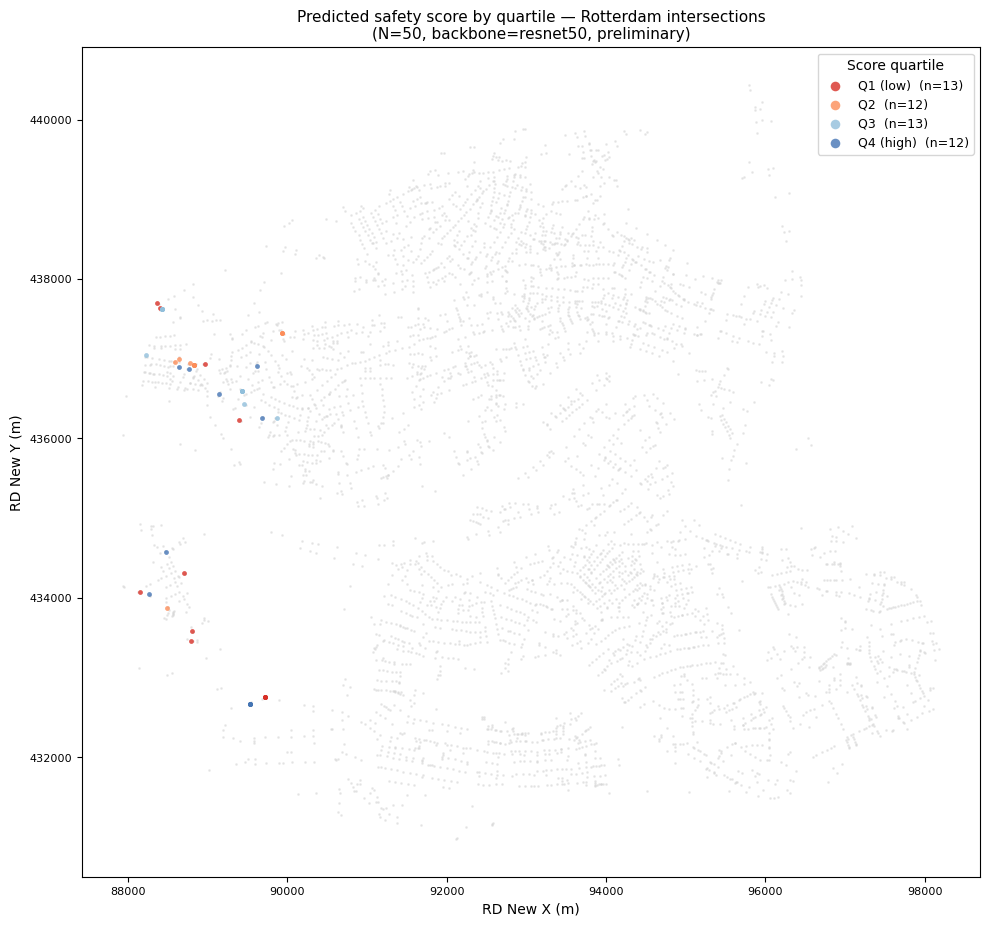

Saved: ..\outputs\nb05_spatial_map.png


In [34]:
# Merge photo coordinates back onto the scores dataframe
coords = df[["intersection_id", "photo_x", "photo_y"]].drop_duplicates("intersection_id")
plot_df = scores_df.merge(coords, on="intersection_id", how="left")
plot_df = plot_df.dropna(subset=["photo_x", "photo_y"])

# Assign quartile labels for colour coding
plot_df["quartile"] = pd.qcut(
    plot_df["cv_score_predicted"],
    q=4,
    labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"],
)
quartile_colours = {
    "Q1 (low)" : "#d73027",
    "Q2"       : "#fc8d59",
    "Q3"       : "#91bfdb",
    "Q4 (high)": "#4575b4",
}

fig, ax = plt.subplots(figsize=(10, 12))

# Optionally overlay the full intersection network as grey dots
try:
    import geopandas as gpd
    if INTERSECTIONS_GPKG.exists():
        gdf = gpd.read_file(INTERSECTIONS_GPKG).to_crs(epsg=28992)
        gdf.plot(ax=ax, color="lightgray", markersize=1, alpha=0.4, zorder=1)
        print(f"Base map: {len(gdf)} intersections from .gpkg")
except ImportError:
    print("geopandas not available — plotting scored intersections only.")

# Plot scored intersections coloured by quartile
for q, colour in quartile_colours.items():
    subset = plot_df[plot_df["quartile"] == q]
    ax.scatter(
        subset["photo_x"], subset["photo_y"],
        c=colour, s=12, alpha=0.8, label=f"{q}  (n={len(subset)})",
        zorder=2, linewidths=0,
    )

ax.set_aspect("equal")
ax.set_xlabel("RD New X (m)")
ax.set_ylabel("RD New Y (m)")
ax.set_title(
    f"Predicted safety score by quartile — Rotterdam intersections\n"
    f"(N={len(plot_df)}, backbone={BACKBONE_NAME}, preliminary)",
    fontsize=11,
)
ax.legend(title="Score quartile", fontsize=9, markerscale=2)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(MAP_PNG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {MAP_PNG}")

## 7. Summary statistics by stratum

Stratum columns (`dim_type`, `dim_priority`, `is_centrum`) come from
`intersections_stratified.gpkg`. If the file is unavailable this section is
skipped gracefully.

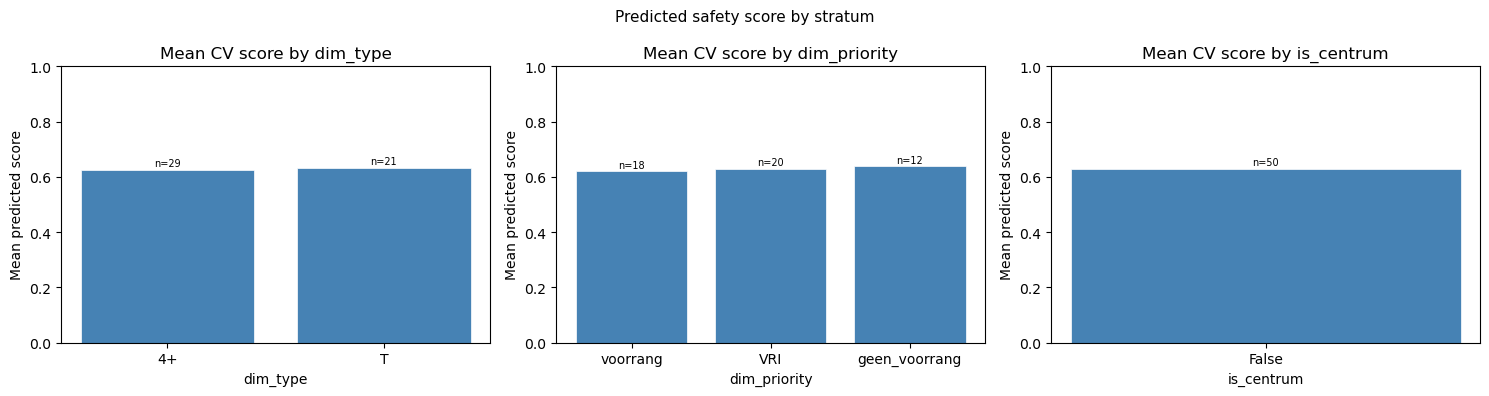

Saved: ..\outputs\nb05_score_distribution.png

--- Mean predicted score by dim_type ---
            mean     std  count
dim_type                       
4+        0.6260  0.0132     29
T         0.6328  0.0131     21

--- Mean predicted score by dim_priority ---
                 mean     std  count
dim_priority                        
VRI            0.6301  0.0118     20
geen_voorrang  0.6380  0.0121     12
voorrang       0.6214  0.0124     18

--- Mean predicted score by is_centrum ---
              mean     std  count
is_centrum                       
False       0.6289  0.0135     50


In [35]:
try:
    import geopandas as gpd

    if not INTERSECTIONS_GPKG.exists():
        raise FileNotFoundError(f"{INTERSECTIONS_GPKG} not found — skipping stratum analysis.")

    gdf = gpd.read_file(INTERSECTIONS_GPKG)

    # The gpkg uses JTE_ID as the intersection identifier; rename to match scores_df
    if "JTE_ID" not in gdf.columns:
        raise ValueError(f"Expected 'JTE_ID' in .gpkg; found: {list(gdf.columns)}")
    gdf = gdf.rename(columns={"JTE_ID": "intersection_id"})

    strat_cols = [c for c in ["dim_type", "dim_priority", "is_centrum"] if c in gdf.columns]
    if not strat_cols:
        raise ValueError("No stratum columns (dim_type, dim_priority, is_centrum) found in .gpkg")

    strat_df = scores_df.merge(
        gdf[["intersection_id"] + strat_cols],
        on="intersection_id",
        how="left",
    )

    fig, axes = plt.subplots(1, len(strat_cols), figsize=(5 * len(strat_cols), 4))
    if len(strat_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, strat_cols):
        grp    = strat_df.groupby(col)["cv_score_predicted"]
        means  = grp.mean().sort_values()
        counts = grp.count()
        bars = ax.bar(means.index.astype(str), means.values,
                      color="steelblue", edgecolor="white", linewidth=0.5)
        for bar, cat in zip(bars, means.index):
            n = counts.get(cat, 0)
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"n={n}", ha="center", va="bottom", fontsize=7)
        ax.set_xlabel(col)
        ax.set_ylabel("Mean predicted score")
        ax.set_title(f"Mean CV score by {col}")
        ax.set_ylim(0, 1)

    plt.suptitle("Predicted safety score by stratum", fontsize=11)
    plt.tight_layout()
    plt.savefig(DIST_PNG, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {DIST_PNG}")

    for col in strat_cols:
        print(f"\n--- Mean predicted score by {col} ---")
        print(
            strat_df.groupby(col)["cv_score_predicted"]
            .agg(["mean", "std", "count"])
            .round(4)
            .to_string()
        )

except (ImportError, FileNotFoundError, ValueError) as e:
    print(f"Stratum analysis skipped: {e}")

## Summary

| | |
|---|---|
| Backbone | ResNet-50 (frozen, linear head) |
| Intersections scored | *[fill from output]* |
| Score range | *[fill from output]* |
| Score mean / std | *[fill from output]* |
| cv_split breakdown | train / val / unlabelled: *[fill]* |
| Scores CSV | `outputs/cv_scores_full_network.csv` |
| Spatial map | `outputs/nb05_spatial_map.png` |

> **Note**: Scores are preliminary — based on a model trained on pilot survey BT
> labels (N=63). Re-run NB01 → NB02 → NB04 → NB05 after real survey data is
> collected to update the scores.

**Next**: Phase 3 — Negative Binomial crash prediction model. Use
`outputs/cv_scores_full_network.csv` as the CV predictor. Exclude `cv_split`
∈ {`train`, `val`} from the NB model test set.